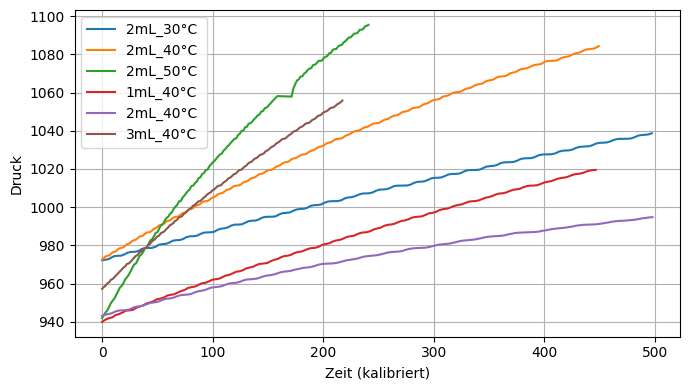

In [42]:
import pandas as pd
import matplotlib.pyplot as plt

# Datei, t_min, t_max, Label
datasets = [
    ("Messung 1.dat", 1000, 1500, "2mL_30°C"),
    ("Messung 2.dat", 500, 950, "2mL_40°C"),
    ("Messung 3,1.dat", 250, 500, "2mL_50°C"),
    ("Teil2_Messung 1.dat", 250, 700, "1mL_40°C"),
    ("Teil 2_Messung 2.dat", 200, 700, "2mL_40°C "),
    ("Teil 2_Messung 3.dat", 190, 410, "3mL_40°C"),
]

plt.figure(figsize=(7,4))

for fname, t_min, t_max, label in datasets:
    df = pd.read_csv(
        fname,
        sep=r"\s+",
        decimal=",",
        header=None,
        names=["t", "p"],
        engine="python"
    )

    # 1) NaN-Werte entfernen
    df = df.dropna()

    # 2) Zeitbereich auswählen
    df_cut = df[(df["t"] >= t_min) & (df["t"] <= t_max)].copy()

    if df_cut.empty:
        print(f"⚠️ Keine gültigen Daten in {fname} im Bereich {t_min}–{t_max}")
        continue

    # 3) Zeit kalibrieren (Ausschnitt startet bei t = 0)
    df_cut["t"] = df_cut["t"] - df_cut["t"].iloc[0]

    plt.plot(df_cut["t"], df_cut["p"], label=label)

plt.xlabel("Zeit (kalibriert)")
plt.ylabel("Druck")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

Messung 1.dat: Δp_inf(frei)=223.26 mbar, k(frei)=7.072e-04 1/s
Messung 2.dat: Δp_inf(frei)=251.29 mbar, k(frei)=1.650e-03 1/s
Messung 3,1.dat: Δp_inf(frei)=246.77 mbar, k(frei)=4.007e-03 1/s

Gemeinsames Δp_inf (fix für alle): 246.77 mbar
Messung 1.dat: k(fix Δp_inf) = 5.8898e-04 ± 7.43e-07 1/s
Messung 2.dat: k(fix Δp_inf) = 1.6931e-03 ± 4.46e-07 1/s
Messung 3,1.dat: k(fix Δp_inf) = 4.0066e-03 ± 4.11e-06 1/s


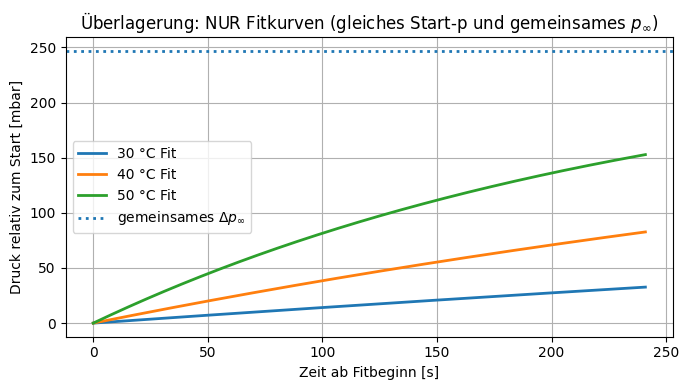


Arrhenius-Auswertung
E_A   = 78.14 kJ/mol
ln(A) = 23.59


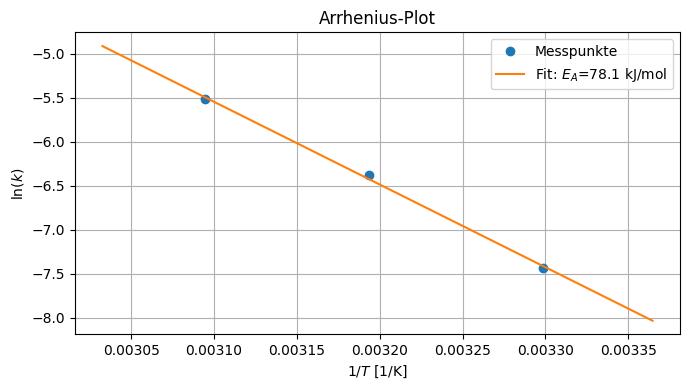

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# =========================================================
# Modell im RELATIVEM Druck:
# Δp(t) = Δp_inf * (1 - exp(-k t))
# mit Δp = p - p_start  -> jede Kurve startet bei 0
# =========================================================
def dp_model(t, dp_inf, k):
    return dp_inf * (1.0 - np.exp(-k * t))

# =========================================================
# Konfiguration: pro Messung Fit-Zeitfenster (ABSOLUTE Zeit in der Datei)
# =========================================================
cfg = {
    "Messung 1.dat":   {"fit_min": 1000, "fit_max": 3500, "label": "30 °C", "T_C": 30},
    "Messung 2.dat":   {"fit_min": 400,  "fit_max": 980,  "label": "40 °C", "T_C": 40},
    "Messung 3,1.dat": {"fit_min": 250,  "fit_max": 500,  "label": "50 °C", "T_C": 50},
}

# =========================================================
# 1) Erster Fit pro Messung: dp_inf_i und k_i bestimmen
# =========================================================
dp_inf_list = []
prepared = {}

for fname, c in cfg.items():
    df = pd.read_csv(
        fname,
        sep=r"\s+",
        decimal=",",
        header=None,
        names=["Zeit", "Druck"],
        engine="python"
    ).dropna()

    t = df["Zeit"].to_numpy(dtype=float)
    p = df["Druck"].to_numpy(dtype=float)

    t_min, t_max = c["fit_min"], c["fit_max"]
    m = (t >= t_min) & (t <= t_max)
    t_abs = t[m]
    p_abs = p[m]

    if len(t_abs) < 6:
        raise ValueError(f"Zu wenige Punkte in {fname} im Fitfenster {t_min}–{t_max} s.")

    # Zeit relativ zum Fitbeginn
    t0 = t_abs[0]
    tt = t_abs - t0

    # relativer Druck (Start bei 0)
    p_start = p_abs[0]
    dp = p_abs - p_start

    # Startwerte
    dp_inf_guess = float(dp.max() * 1.05)
    k_guess = 1e-3

    popt, pcov = curve_fit(
        dp_model, tt, dp,
        p0=[dp_inf_guess, k_guess],
        bounds=([0.0, 0.0], [np.inf, np.inf])
    )

    dp_inf_i, k_i = map(float, popt)
    dp_inf_list.append(dp_inf_i)

    prepared[fname] = {
        "cfg": c,
        "tt": tt,
        "dp": dp,
        "k_guess": k_i,
        "tt_max": float(tt.max())
    }

    print(f"{fname}: Δp_inf(frei)={dp_inf_i:.2f} mbar, k(frei)={k_i:.3e} 1/s")

# gemeinsames Δp_inf festlegen
dp_inf_common = float(np.median(dp_inf_list))  # robust
print("\n" + "="*60)
print(f"Gemeinsames Δp_inf (fix für alle): {dp_inf_common:.2f} mbar")

# =========================================================
# 2) Refit: Δp_inf fix -> nur k fitten
# =========================================================
T_list, k_list = [], []
fit_lines = []  # (label, t_line, dp_line)

for fname, d in prepared.items():
    c = d["cfg"]
    tt = d["tt"]
    dp = d["dp"]

    def dp_model_fixed(t, k):
        return dp_model(t, dp_inf_common, k)

    popt, pcov = curve_fit(
        dp_model_fixed, tt, dp,
        p0=[d["k_guess"]],
        bounds=([0.0], [np.inf])
    )

    k_fit = float(popt[0])
    k_err = float(np.sqrt(np.diag(pcov))[0]) if pcov.size else np.nan

    print(f"{fname}: k(fix Δp_inf) = {k_fit:.4e} ± {k_err:.2e} 1/s")

    T_list.append(c["T_C"] + 273.15)
    k_list.append(k_fit)

    # Fit-Linie: alle bis zur GLEICHEN ZEIT (damit die Kurven gleich lang sind)
    # -> gemeinsame Zeitachse = Minimum der Fitfenster-Längen
    # (sonst endet jede Kurve bei einer anderen maximalen tt)
    # Wir bestimmen die gemeinsame Zeit NACH der Schleife; hier nur speichern.
    fit_lines.append((c["label"], k_fit, d["tt_max"]))

# gemeinsame maximale Zeit (alle Linien gleich lang)
t_common_max = float(min(tt_max for _, _, tt_max in fit_lines))
t_common = np.linspace(0.0, t_common_max, 500)

# =========================================================
# 3) Sammelplot: NUR Fit-Linien (keine Punkte)
# =========================================================
plt.figure(figsize=(7,4))

for label, k_fit, _ in fit_lines:
    dp_line = dp_model(t_common, dp_inf_common, k_fit)
    plt.plot(t_common, dp_line, "-", linewidth=2, label=f"{label} Fit")

plt.axhline(dp_inf_common, linestyle=":", linewidth=2, label=r"gemeinsames $\Delta p_\infty$")
plt.xlabel("Zeit ab Fitbeginn [s]")
plt.ylabel("Druck relativ zum Start [mbar]")
plt.title("Überlagerung: NUR Fitkurven (gleiches Start-p und gemeinsames $p_\\infty$)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# =========================================================
# 4) Arrhenius-Plot (optional)
# =========================================================
T = np.array(T_list, dtype=float)
k = np.array(k_list, dtype=float)

x = 1.0 / T
y = np.log(k)

m, b = np.polyfit(x, y, 1)
R = 8.314
E_A_kJ = (-m * R) / 1000

print("\n" + "="*60)
print("Arrhenius-Auswertung")
print(f"E_A   = {E_A_kJ:.2f} kJ/mol")
print(f"ln(A) = {b:.2f}")

x_fit = np.linspace(x.min()*0.98, x.max()*1.02, 200)
y_fit = m * x_fit + b

plt.figure(figsize=(7,4))
plt.plot(x, y, "o", label="Messpunkte")
plt.plot(x_fit, y_fit, "-", label=f"Fit: $E_A$={E_A_kJ:.1f} kJ/mol")
plt.xlabel(r"$1/T$ [1/K]")
plt.ylabel(r"$\ln(k)$")
plt.title("Arrhenius-Plot")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()